In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv("unsw-nb/UNSW_NB15_training-set.csv")

In [5]:
data.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [6]:
# number of attack labels 
data['attack_cat'].value_counts()

Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: attack_cat, dtype: int64

In [7]:
#print(data.info())
data = pd.concat([
    data[data.attack_cat == 'DoS'],
    data[data.attack_cat == 'Exploits'],
    data[data.attack_cat == 'Fuzzers'],
    data[data.attack_cat == 'Generic'],
    data[data.attack_cat == 'Normal'],
    data[data.attack_cat == 'Reconnaissance']
])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 80650 entries, 246 to 65846
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 80650 non-null  int64  
 1   dur                80650 non-null  float64
 2   proto              80650 non-null  object 
 3   service            80650 non-null  object 
 4   state              80650 non-null  object 
 5   spkts              80650 non-null  int64  
 6   dpkts              80650 non-null  int64  
 7   sbytes             80650 non-null  int64  
 8   dbytes             80650 non-null  int64  
 9   rate               80650 non-null  float64
 10  sttl               80650 non-null  int64  
 11  dttl               80650 non-null  int64  
 12  sload              80650 non-null  float64
 13  dload              80650 non-null  float64
 14  sloss              80650 non-null  int64  
 15  dloss              80650 non-null  int64  
 16  sinpkt             8

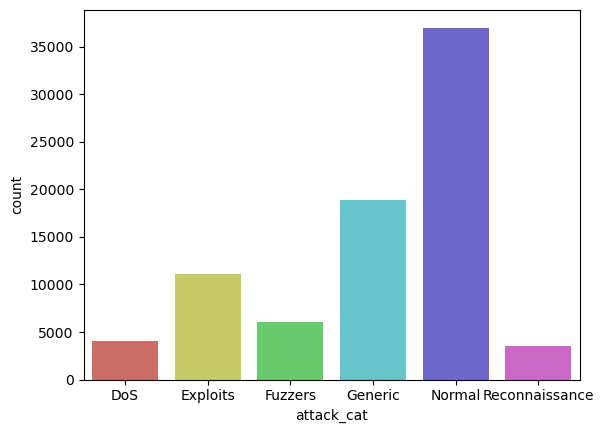

In [10]:
sns.countplot(x='attack_cat',data=data, palette='hls')
plt.show()
#plt.savefig('count_plot') mal: the nodule malignancy, 0: benign, 1: malignant

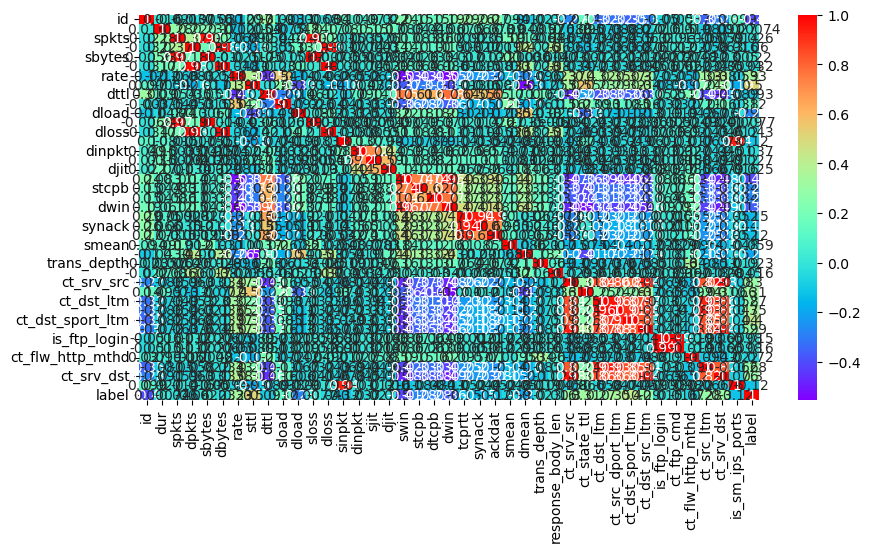

In [11]:
plt.figure(figsize = (10,5))
sns.heatmap(data.corr(), annot = True, cmap="rainbow")
plt.show()

In [8]:
del data['id']
del data['proto']
del data['service']
del data['state']
del data['label']

In [9]:
# Import label encoder 
from sklearn import preprocessing 

# label_encoder object knows 
# how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 

# Encode labels in column 'species'. 
data['attack_cat']= label_encoder.fit_transform(data['attack_cat'])

In [10]:
X = data.drop(["attack_cat"],axis =1)
y = data["attack_cat"]

# Filter Method

In [11]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [12]:
selector = SelectKBest(f_classif, k=8) # k is the number of features to be selected
X_new = selector.fit_transform(X, y)

In [13]:
selected_features = data.columns[:-1][selector.get_support()]
print("\nSelected Features:")
print(selected_features)


Selected Features:
Index(['sttl', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst'],
      dtype='object')


In [14]:
df = data[['sttl', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst','attack_cat']]

In [15]:
X = df.drop(["attack_cat"],axis =1)
y = df["attack_cat"]

In [16]:
from imblearn.over_sampling import SMOTE
smt = SMOTE()
X_sm, y_sm = smt.fit_resample(X, y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_sm, y_sm, test_size = 0.20, random_state = 42)

In [18]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [20]:
from sklearn.metrics import accuracy_score # for calculating accuracy of model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_rec = recall_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')

In [21]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# Decision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(min_samples_leaf=20,criterion="entropy", max_depth=3,random_state=10)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_valid)

dt_acc = accuracy_score(y_pred, y_valid)
dt_prec = precision_score(y_pred, y_valid,average='weighted')
dt_rec = recall_score(y_pred, y_valid,average='weighted')
dt_f1 = f1_score(y_pred, y_valid,average='weighted')

In [23]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1)

# AdaBoost

In [24]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred    = ada.predict(X_valid)

ada_acc = accuracy_score(y_pred, y_valid)
ada_prec = precision_score(y_pred, y_valid,average='weighted')
ada_rec = recall_score(y_pred, y_valid,average='weighted')
ada_f1 = f1_score(y_pred, y_valid,average='weighted')

In [25]:
storeResults('AdaBoost',ada_acc,ada_prec,ada_rec,ada_f1)

# BernoulliNB

In [26]:
from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred    = nb.predict(X_valid)

nb_acc = accuracy_score(y_pred, y_valid)
nb_prec = precision_score(y_pred, y_valid,average='weighted')
nb_rec = recall_score(y_pred, y_valid,average='weighted')
nb_f1 = f1_score(y_pred, y_valid,average='weighted')

In [27]:
storeResults('BernoulliNB',nb_acc,nb_prec,nb_rec,nb_f1)

# KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred    = knn.predict(X_valid)

knn_acc = accuracy_score(y_pred, y_valid)
knn_prec = precision_score(y_pred, y_valid,average='weighted')
knn_rec = recall_score(y_pred, y_valid,average='weighted')
knn_f1 = f1_score(y_pred, y_valid,average='weighted')

In [29]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_rec = recall_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')

In [31]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

# Extension 

In [32]:
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bdt = AdaBoostClassifier(DecisionTreeClassifier())
bag = BaggingClassifier(RandomForestClassifier())

clf = VotingClassifier(estimators= [('BoostedDT', bdt),('BagRF', bag)], voting='soft')

clf.fit(X_train, y_train)

y_pred    = clf.predict(X_valid)

vot_acc = accuracy_score(y_pred, y_valid)
vot_prec = precision_score(y_pred, y_valid,average='weighted')
vot_rec = recall_score(y_pred, y_valid,average='weighted')
vot_f1 = f1_score(y_pred, y_valid,average='weighted')

In [34]:
storeResults('Extension',vot_acc,vot_prec,vot_rec,vot_f1)

# Comparison

In [35]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                      })

In [36]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.752,0.758,0.752,0.751
1,Decision Tree,0.601,0.715,0.601,0.619
2,AdaBoost,0.529,0.656,0.529,0.567
3,BernoulliNB,0.170,0.994,0.170,0.283
4,KNN,0.652,0.754,0.652,0.660
5,Logistic Regression,0.594,0.637,0.594,0.598
6,Extension,0.797,0.804,0.797,0.797


# Graph

In [37]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

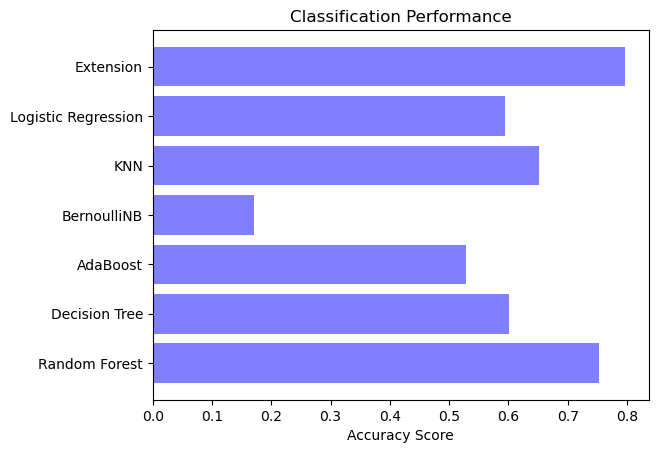

In [38]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

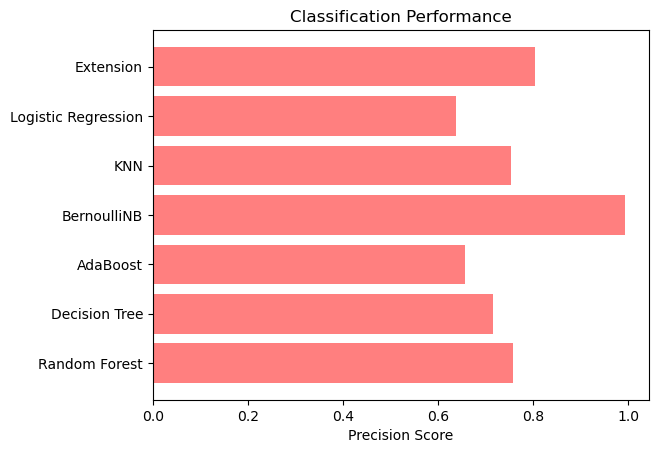

In [39]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

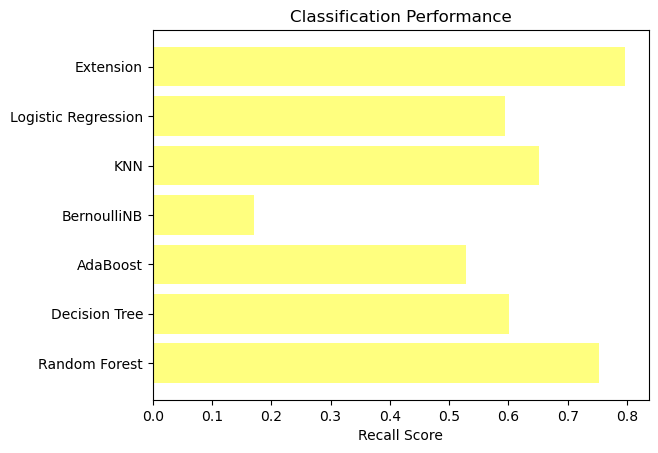

In [40]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

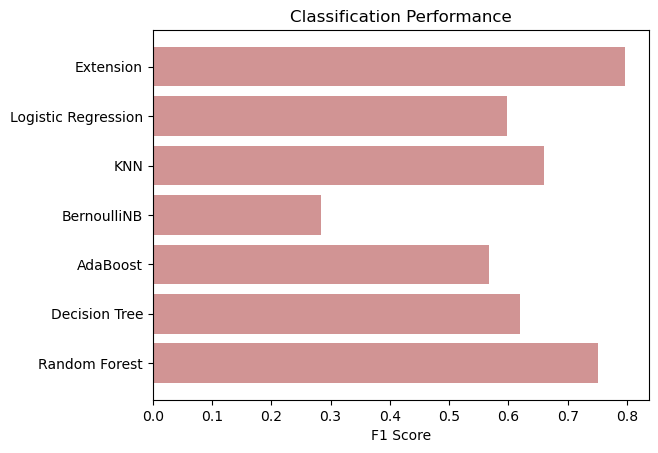

In [41]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Wrapper Method

In [11]:
X = data.drop(["attack_cat"],axis =1)
y = data["attack_cat"]

In [12]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor()
n_features_to_select = 10
rfe = RFE(regressor, n_features_to_select=n_features_to_select)

In [13]:
rfe.fit(X,y)

RFE(estimator=RandomForestRegressor(), n_features_to_select=10)

In [14]:
#to get number of the features
display('Number of features:', rfe.n_features_)

#to get feature names
list(X.columns[rfe.support_]) 

'Number of features:'

10

['dur',
 'sbytes',
 'dbytes',
 'sttl',
 'sload',
 'synack',
 'smean',
 'ct_src_dport_ltm',
 'ct_dst_src_ltm',
 'ct_srv_dst']

In [15]:
df = data[['dur',
         'sbytes',
         'dbytes',
         'sttl',
         'sload',
         'synack',
         'smean',
         'ct_src_dport_ltm',
         'ct_dst_src_ltm',
         'ct_srv_dst','attack_cat']]

In [16]:
X = df.drop(["attack_cat"],axis =1)
y = df["attack_cat"]

In [17]:
from imblearn.over_sampling import SMOTE
smt = SMOTE()
X_sm, y_sm = smt.fit_resample(X, y)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_sm, y_sm, test_size = 0.20, random_state = 42)

In [19]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_rec = recall_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')

In [22]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(min_samples_leaf=20,criterion="entropy", max_depth=3,random_state=10)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_valid)

dt_acc = accuracy_score(y_pred, y_valid)
dt_prec = precision_score(y_pred, y_valid,average='weighted')
dt_rec = recall_score(y_pred, y_valid,average='weighted')
dt_f1 = f1_score(y_pred, y_valid,average='weighted')

In [24]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1)

# AdaBoost

In [25]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred    = ada.predict(X_valid)

ada_acc = accuracy_score(y_pred, y_valid)
ada_prec = precision_score(y_pred, y_valid,average='weighted')
ada_rec = recall_score(y_pred, y_valid,average='weighted')
ada_f1 = f1_score(y_pred, y_valid,average='weighted')

In [26]:
storeResults('AdaBoost',ada_acc,ada_prec,ada_rec,ada_f1)

# BernoulliNB

In [27]:
from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred    = nb.predict(X_valid)

nb_acc = accuracy_score(y_pred, y_valid)
nb_prec = precision_score(y_pred, y_valid,average='weighted')
nb_rec = recall_score(y_pred, y_valid,average='weighted')
nb_f1 = f1_score(y_pred, y_valid,average='weighted')

In [28]:
storeResults('BernoulliNB',nb_acc,nb_prec,nb_rec,nb_f1)

# KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred    = knn.predict(X_valid)

knn_acc = accuracy_score(y_pred, y_valid)
knn_prec = precision_score(y_pred, y_valid,average='weighted')
knn_rec = recall_score(y_pred, y_valid,average='weighted')
knn_f1 = f1_score(y_pred, y_valid,average='weighted')

In [30]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# LogisticRegression

In [31]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='ovr', solver='liblinear')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_rec = recall_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')

In [32]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

# Extension

In [33]:
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bdt = AdaBoostClassifier(DecisionTreeClassifier())
bag = BaggingClassifier(RandomForestClassifier())

clf = VotingClassifier(estimators= [('BoostedDT', bdt),('BagRF', bag)], voting='soft')

clf.fit(X_train, y_train)

y_pred    = clf.predict(X_valid)

vot_acc = accuracy_score(y_pred, y_valid)
vot_prec = precision_score(y_pred, y_valid,average='weighted')
vot_rec = recall_score(y_pred, y_valid,average='weighted')
vot_f1 = f1_score(y_pred, y_valid,average='weighted')

In [35]:
storeResults('Extension',vot_acc,vot_prec,vot_rec,vot_f1)

# Comparison

In [36]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                      })

In [37]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.871,0.871,0.871,0.869
1,Decision Tree,0.604,0.773,0.604,0.648
2,AdaBoost,0.668,0.699,0.668,0.666
3,BernoulliNB,0.296,0.862,0.296,0.436
4,KNN,0.799,0.800,0.799,0.797
5,Logistic Regression,0.174,0.702,0.174,0.269
6,Extension,0.954,0.955,0.954,0.953


# Modelling

In [38]:
import joblib
filename = 'model_wapper.sav'
joblib.dump(clf, filename)

['model_wapper.sav']

# Graph

In [40]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

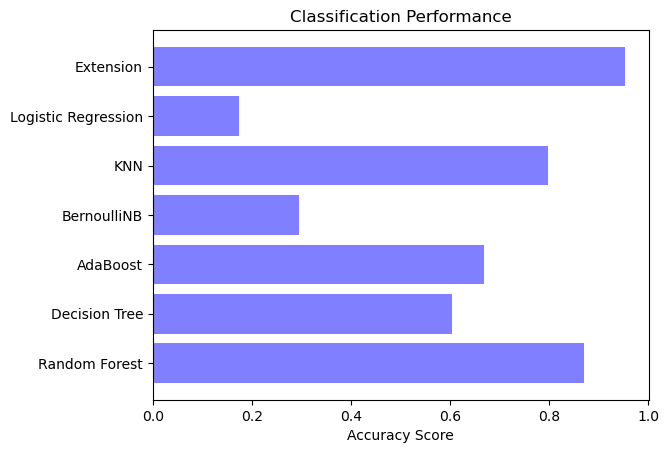

In [41]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

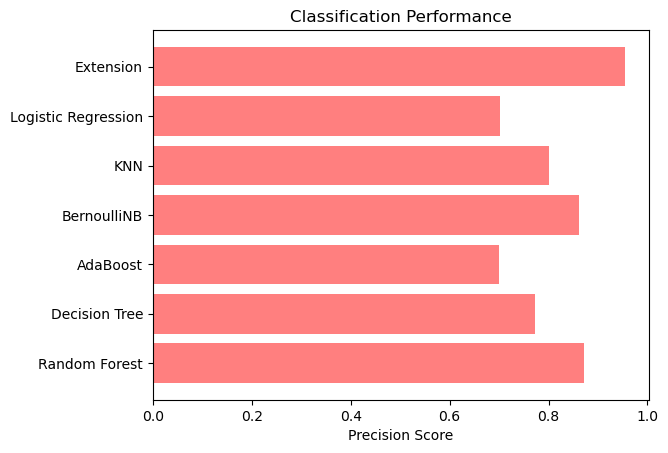

In [42]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

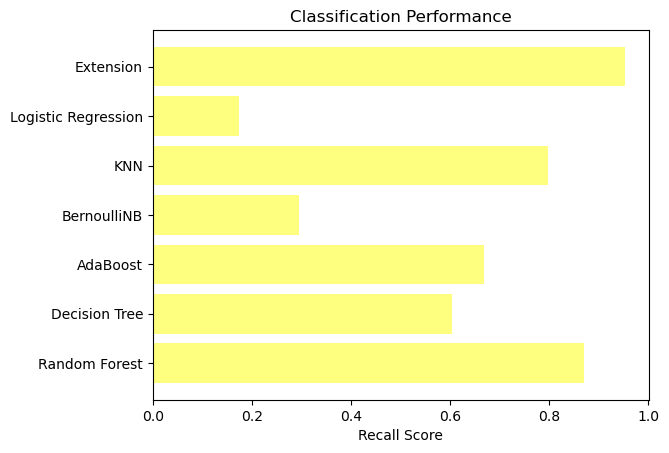

In [43]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

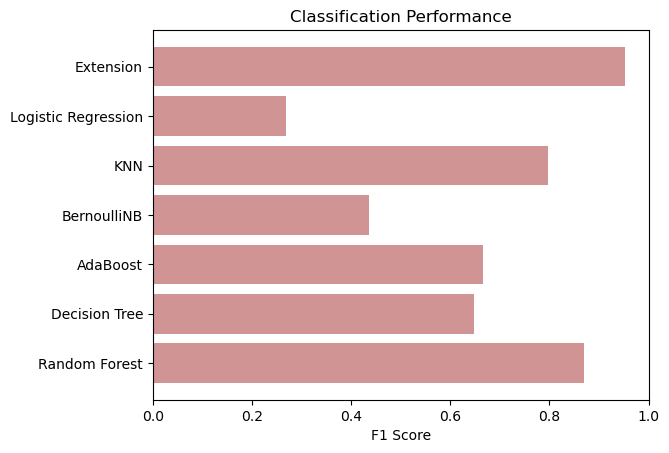

In [44]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Embedded Method

In [45]:
X = data.drop(["attack_cat"],axis =1)
y = data["attack_cat"]

In [46]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

In [47]:
selector = SelectKBest(f_classif, k=18) # k is the number of features to be selected
X_new = selector.fit_transform(X, y)

In [48]:
selected_features = data.columns[:-1][selector.get_support()]
print("\nSelected Features:")
print(selected_features)


Selected Features:
Index(['rate', 'sttl', 'dttl', 'dload', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'ackdat', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm',
       'ct_srv_dst'],
      dtype='object')


In [49]:
df = data[['rate', 'sttl', 'dttl', 'dload', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'ackdat', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm',
       'ct_srv_dst','attack_cat']]

In [50]:
X = df.drop(["attack_cat"],axis =1)
y = df["attack_cat"]

In [51]:
rfe.fit(X,y)

RFE(estimator=RandomForestRegressor(), n_features_to_select=10)

In [52]:
#to get number of the features
display('Number of features:', rfe.n_features_)

#to get feature names
list(X.columns[rfe.support_]) 

'Number of features:'

10

['rate',
 'sttl',
 'dload',
 'ackdat',
 'dmean',
 'ct_srv_src',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'ct_src_ltm',
 'ct_srv_dst']

In [95]:
df = data[['rate',
             'sttl',
             'dload',
             'ackdat',
             'dmean',
             'ct_srv_src',
             'ct_dst_sport_ltm',
             'ct_dst_src_ltm',
             'ct_src_ltm',
             'ct_srv_dst','attack_cat']]

In [96]:
X = df.drop(["attack_cat"],axis =1)
y = df["attack_cat"]

In [97]:
smt = SMOTE()
X_sm, y_sm = smt.fit_resample(X, y)

In [98]:
X_train, X_valid, y_train, y_valid = train_test_split(X_sm, y_sm, test_size = 0.20, random_state = 42)

In [99]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# Random Forest

In [100]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_rec = recall_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')

In [101]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# DecisionTree

In [102]:
dt = DecisionTreeClassifier(min_samples_leaf=20,criterion="entropy", max_depth=3,random_state=10)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_valid)

dt_acc = accuracy_score(y_pred, y_valid)
dt_prec = precision_score(y_pred, y_valid,average='weighted')
dt_rec = recall_score(y_pred, y_valid,average='weighted')
dt_f1 = f1_score(y_pred, y_valid,average='weighted')

In [103]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1)

# AdaBoost

In [104]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred    = ada.predict(X_valid)

ada_acc = accuracy_score(y_pred, y_valid)
ada_prec = precision_score(y_pred, y_valid,average='weighted')
ada_rec = recall_score(y_pred, y_valid,average='weighted')
ada_f1 = f1_score(y_pred, y_valid,average='weighted')

In [105]:
storeResults('AdaBoost',ada_acc,ada_prec,ada_rec,ada_f1)

# BernoulliNB

In [106]:
from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred    = nb.predict(X_valid)

nb_acc = accuracy_score(y_pred, y_valid)
nb_prec = precision_score(y_pred, y_valid,average='weighted')
nb_rec = recall_score(y_pred, y_valid,average='weighted')
nb_f1 = f1_score(y_pred, y_valid,average='weighted')

In [107]:
storeResults('BernoulliNB',nb_acc,nb_prec,nb_rec,nb_f1)

# KNN

In [108]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred    = knn.predict(X_valid)

knn_acc = accuracy_score(y_pred, y_valid)
knn_prec = precision_score(y_pred, y_valid,average='weighted')
knn_rec = recall_score(y_pred, y_valid,average='weighted')
knn_f1 = f1_score(y_pred, y_valid,average='weighted')

In [109]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# LogisticRegression

In [110]:
lr = LogisticRegression(multi_class='ovr', solver='liblinear')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_rec = recall_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')

In [111]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

# Extension

In [68]:
clf.fit(X_train, y_train)

y_pred    = clf.predict(X_valid)

vot_acc = accuracy_score(y_pred, y_valid)
vot_prec = precision_score(y_pred, y_valid,average='weighted')
vot_rec = recall_score(y_pred, y_valid,average='weighted')
vot_f1 = f1_score(y_pred, y_valid,average='weighted')

In [112]:
storeResults('Extension',vot_acc,vot_prec,vot_rec,vot_f1)

# Comparison

In [113]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                      })

In [114]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.836,0.835,0.836,0.835
1,Decision Tree,0.578,0.703,0.578,0.603
2,AdaBoost,0.647,0.665,0.647,0.652
3,BernoulliNB,0.298,0.888,0.298,0.444
4,KNN,0.724,0.725,0.724,0.721
5,Logistic Regression,0.500,0.592,0.500,0.516
6,Extension,0.957,0.957,0.957,0.956


# Modelling

In [72]:
import joblib
filename = 'model_emb.sav'
joblib.dump(clf, filename)

['model_emb.sav']

# Graph

In [115]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

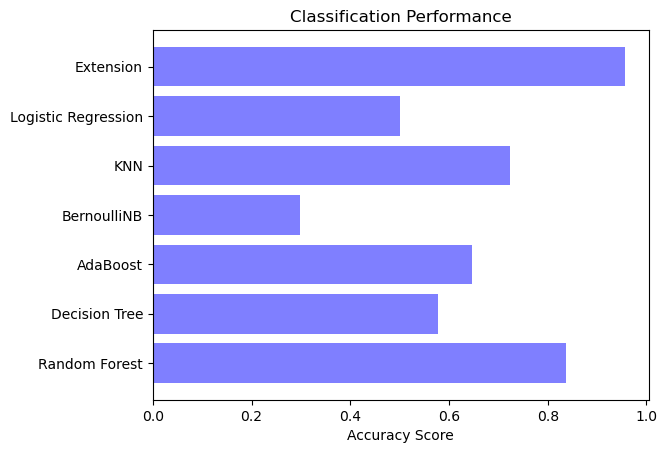

In [116]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

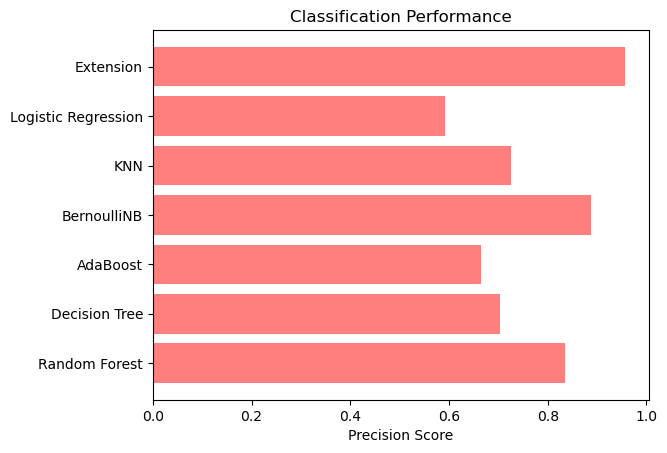

In [117]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

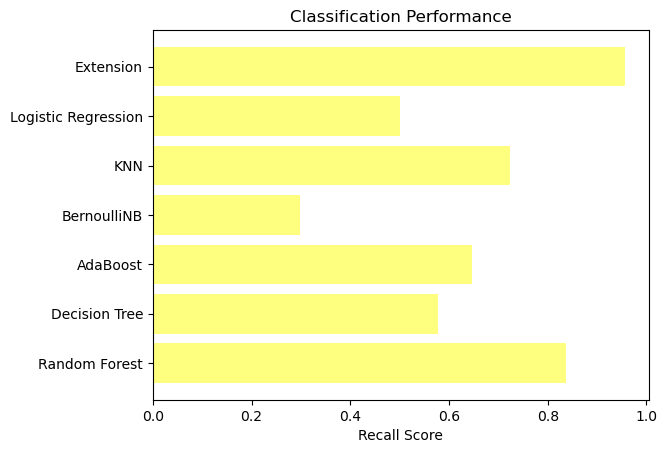

In [118]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

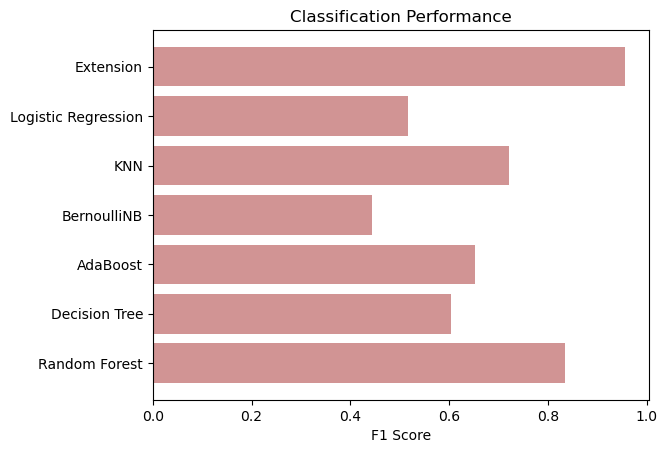

In [119]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# PCC

In [79]:
X = data.drop(["attack_cat"],axis =1)
y = data["attack_cat"]

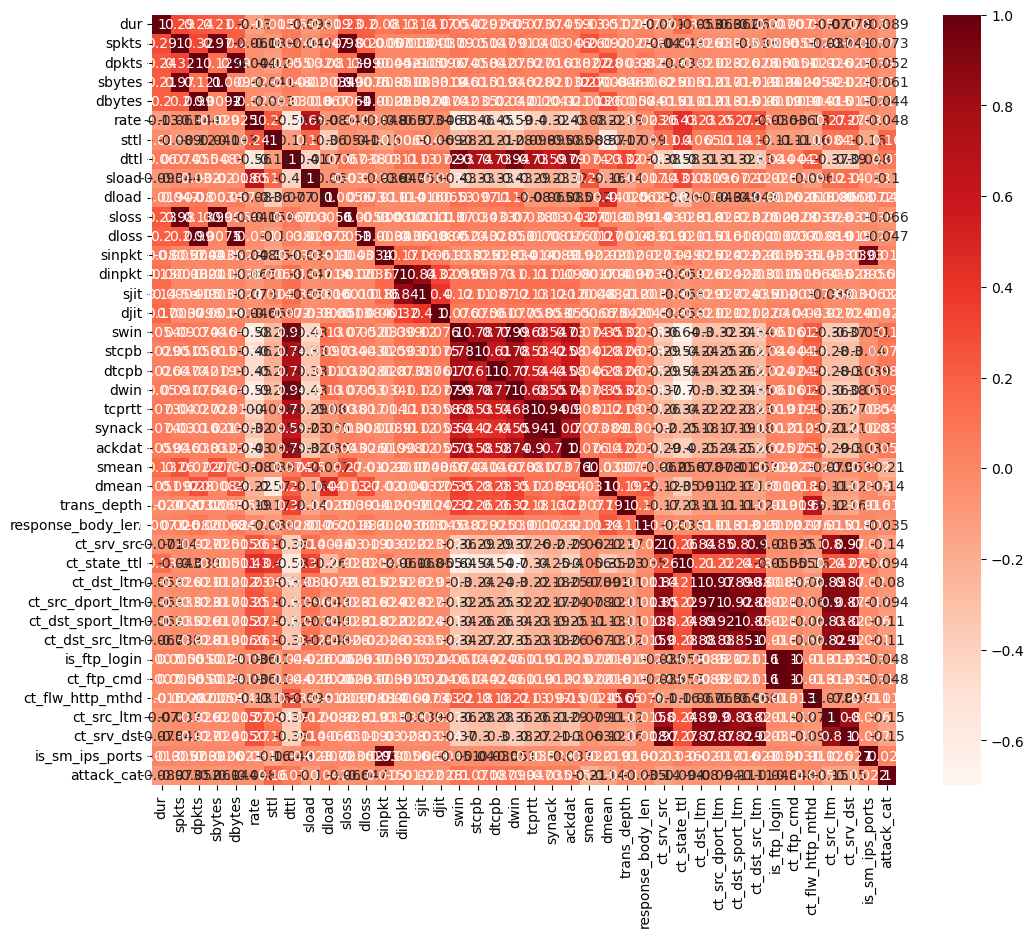

In [80]:
#Using Correlation
plt.figure(figsize=(12,10))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [82]:
#Correlation with output variable
cor_target = abs(cor["attack_cat"])
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0.1]
relevant_features

sttl                0.161145
swin                0.102792
smean               0.214671
dmean               0.136246
ct_srv_src          0.141828
ct_dst_sport_ltm    0.111285
ct_dst_src_ltm      0.105911
ct_src_ltm          0.146676
ct_srv_dst          0.153756
attack_cat          1.000000
Name: attack_cat, dtype: float64

In [120]:
df = data[['sttl','swin','smean','dmean','ct_srv_src','ct_dst_sport_ltm',
          'ct_dst_src_ltm','ct_src_ltm','ct_srv_dst','attack_cat']]

In [121]:
X = df.drop(["attack_cat"],axis =1)
y = df["attack_cat"]

In [122]:
X_sm, y_sm = smt.fit_resample(X, y)

In [123]:
X_train, X_valid, y_train, y_valid = train_test_split(X_sm, y_sm, test_size = 0.20, random_state = 42)

In [124]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# Random Forest

In [125]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_valid)

rf_acc = accuracy_score(y_pred, y_valid)
rf_prec = precision_score(y_pred, y_valid,average='weighted')
rf_rec = recall_score(y_pred, y_valid,average='weighted')
rf_f1 = f1_score(y_pred, y_valid,average='weighted')

In [126]:
storeResults('Random Forest',rf_acc,rf_prec,rf_rec,rf_f1)

# DecisionTree

In [127]:
dt = DecisionTreeClassifier(min_samples_leaf=20,criterion="entropy", max_depth=3,random_state=10)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_valid)

dt_acc = accuracy_score(y_pred, y_valid)
dt_prec = precision_score(y_pred, y_valid,average='weighted')
dt_rec = recall_score(y_pred, y_valid,average='weighted')
dt_f1 = f1_score(y_pred, y_valid,average='weighted')

In [128]:
storeResults('Decision Tree',dt_acc,dt_prec,dt_rec,dt_f1)

# AdaBoost

In [129]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred    = ada.predict(X_valid)

ada_acc = accuracy_score(y_pred, y_valid)
ada_prec = precision_score(y_pred, y_valid,average='weighted')
ada_rec = recall_score(y_pred, y_valid,average='weighted')
ada_f1 = f1_score(y_pred, y_valid,average='weighted')

In [130]:
storeResults('AdaBoost',ada_acc,ada_prec,ada_rec,ada_f1)

# BernoulliNB

In [131]:
nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred    = nb.predict(X_valid)

nb_acc = accuracy_score(y_pred, y_valid)
nb_prec = precision_score(y_pred, y_valid,average='weighted')
nb_rec = recall_score(y_pred, y_valid,average='weighted')
nb_f1 = f1_score(y_pred, y_valid,average='weighted')

In [132]:
storeResults('BernoulliNB',nb_acc,nb_prec,nb_rec,nb_f1)

# KNN

In [133]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred    = knn.predict(X_valid)

knn_acc = accuracy_score(y_pred, y_valid)
knn_prec = precision_score(y_pred, y_valid,average='weighted')
knn_rec = recall_score(y_pred, y_valid,average='weighted')
knn_f1 = f1_score(y_pred, y_valid,average='weighted')

In [134]:
storeResults('KNN',knn_acc,knn_prec,knn_rec,knn_f1)

# Logistic Regression

In [135]:
lr = LogisticRegression(multi_class='ovr', solver='liblinear')
lr.fit(X_train, y_train)

y_pred    = lr.predict(X_valid)

lr_acc = accuracy_score(y_pred, y_valid)
lr_prec = precision_score(y_pred, y_valid,average='weighted')
lr_rec = recall_score(y_pred, y_valid,average='weighted')
lr_f1 = f1_score(y_pred, y_valid,average='weighted')

In [136]:
storeResults('Logistic Regression',lr_acc,lr_prec,lr_rec,lr_f1)

# Extension

In [137]:
clf.fit(X_train, y_train)

y_pred    = clf.predict(X_valid)

vot_acc = accuracy_score(y_pred, y_valid)
vot_prec = precision_score(y_pred, y_valid,average='weighted')
vot_rec = recall_score(y_pred, y_valid,average='weighted')
vot_f1 = f1_score(y_pred, y_valid,average='weighted')

In [138]:
storeResults('Extension',vot_acc,vot_prec,vot_rec,vot_f1)

# Comparison

In [139]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score
                      })

In [140]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.871,0.874,0.871,0.870
1,Decision Tree,0.601,0.740,0.601,0.621
2,AdaBoost,0.680,0.705,0.680,0.686
3,BernoulliNB,0.282,0.818,0.282,0.417
4,KNN,0.843,0.844,0.843,0.841
5,Logistic Regression,0.633,0.697,0.633,0.653
6,Extension,0.939,0.941,0.939,0.939


# Graph

In [141]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

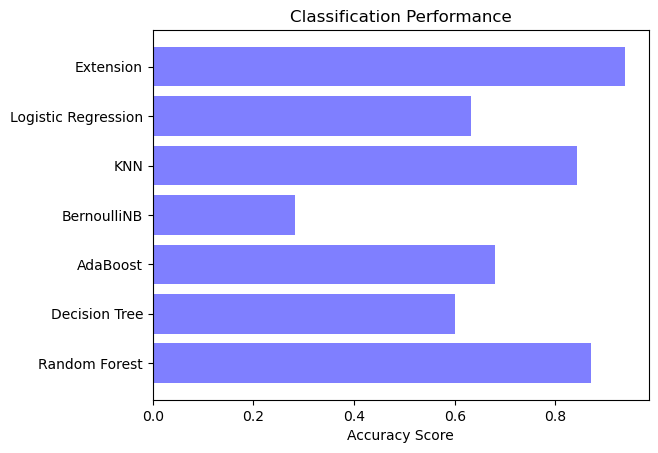

In [142]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

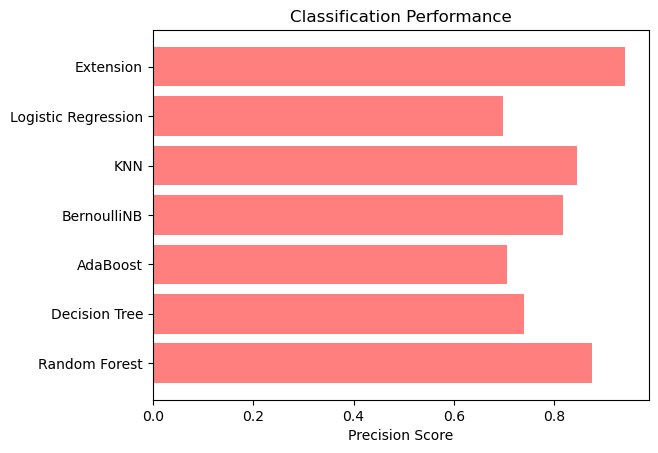

In [143]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

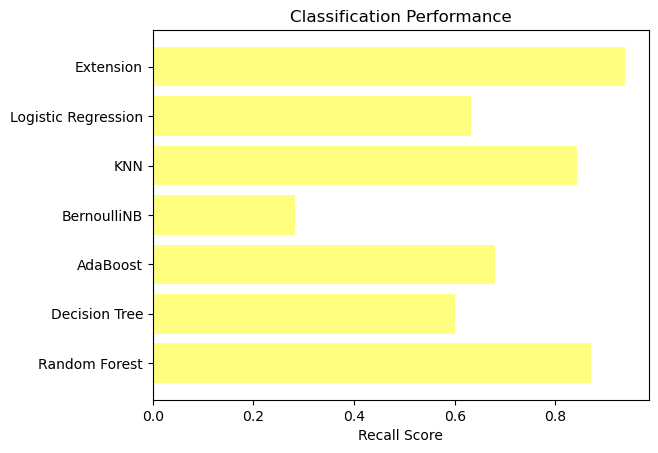

In [144]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

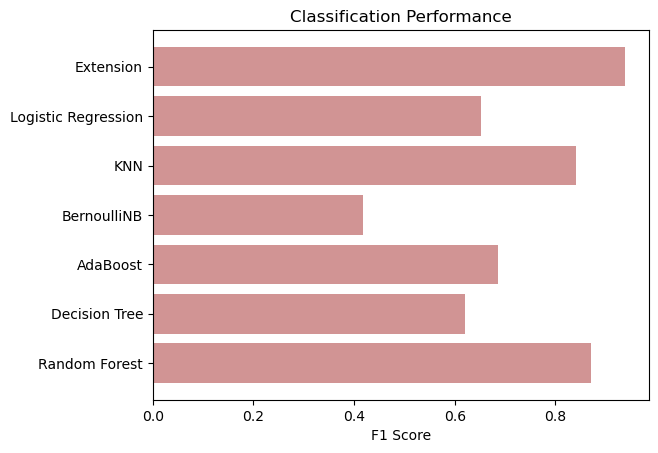

In [145]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()